In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("hourly_taxi_data.csv")

df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

df.head()

,pickup_datetime,trips,avg_fare
0,2008-12-31 23:00:00,1,70.000000
1,2009-01-01 00:00:00,1,8.600000
2,2009-01-01 14:00:00,1,50.600000
3,2025-08-31 23:00:00,6,15.600000
4,2025-09-01 00:00:00,2317,23.345093


In [3]:
df["hour"] = df["pickup_datetime"].dt.hour
df["day_of_week"] = df["pickup_datetime"].dt.dayofweek

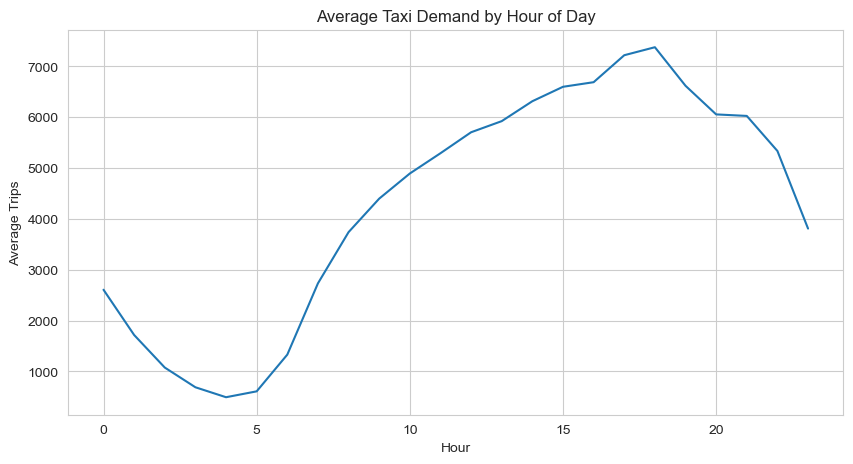

In [5]:
hourly = df.groupby("hour")["trips"].mean()

plt.figure(figsize=(10,5))
hourly.plot()

plt.title("Average Taxi Demand by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Trips")

plt.savefig("demand_by_hour.png")
plt.show()

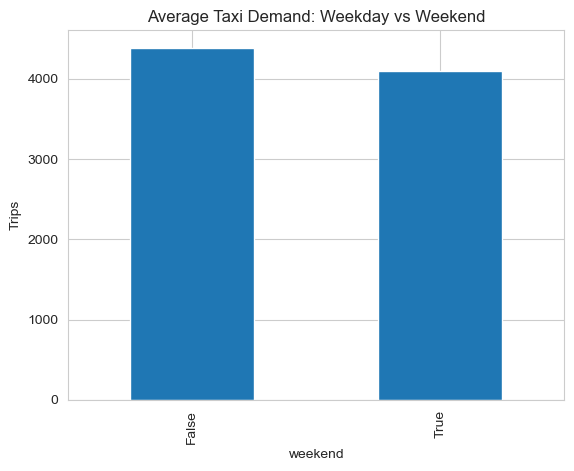

In [6]:
df["weekend"] = df["day_of_week"] >= 5

weekend_demand = df.groupby("weekend")["trips"].mean()

weekend_demand.plot(kind="bar")

plt.title("Average Taxi Demand: Weekday vs Weekend")
plt.ylabel("Trips")

plt.savefig("weekend_vs_weekday_demand.png")
plt.show()

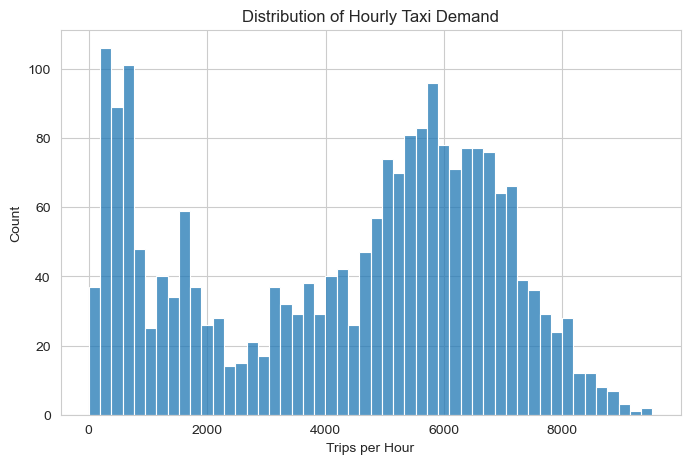

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df["trips"], bins=50)

plt.title("Distribution of Hourly Taxi Demand")
plt.xlabel("Trips per Hour")

plt.savefig("demand_distribution.png")
plt.show()